# Student project : Process Optimization 

Previous supervisor: Dr. Erik Esche

Author: Gbocho Alexandre 


This file presents a project completed during my Master’s studies in process and chemical engineering at the DBTA (https://www.tu.berlin/dbta).

For copyright reasons, the original script is not shared here; only few descriptions and code are available. 

A Continuously Stirred Tank Reactor (CSTR) is an open chemical reactor equipped with an impeller to ensure continuous mixing, where reactants flow in continuously and products flow out simultaneously. Assuming perfect mixing, the concentration and temperature inside the reactor are completely uniform and equal to the outlet stream conditions.The primary goal in this problem is to determine an optimal temperature control trajectory ($T_0$ and $T_j$) over a 1-hour time horizon ($3600\text{ s}$) to maximize the desired product concentration ($c_A$) as quickly as possible while keeping the reactor temperature $T(t) \le 350\text{ K}$.


# System : 

\begin{aligned}
\frac{\partial c_A}{\partial t} &= \frac{\dot{F}}{V}(c_{A0} - c_A) - k_{A0} \cdot c_A \cdot e^{-\frac{E_A}{R \cdot T}} + k_{B0} \cdot c_B \cdot e^{-\frac{E_B}{R \cdot T}} \\[12pt]
\frac{\partial c_B}{\partial t} &= \frac{\dot{F}}{V}(c_{B0} - c_B) - k_{B0} \cdot c_B \cdot e^{-\frac{E_B}{R \cdot T}} \\[12pt]
\frac{\partial T}{\partial t} &= \frac{\dot{F}}{V}(T_0 - T) + \frac{U \cdot A}{\rho \cdot c_p \cdot V}(T_j - T) + \frac{(-\Delta H_A)}{\rho \cdot c_p} \cdot k_{A0} \cdot c_A \cdot e^{-\frac{E_A}{R \cdot T}} + \frac{(-\Delta H_B)}{\rho \cdot c_p} \cdot k_{B0} \cdot c_B \cdot e^{-\frac{E_B}{R \cdot T}}
\end{aligned}

# Numerical values & model parameters 

\begin{aligned}
E_A &= 69 \cdot 10^3 \; \text{J/mol} \\[4pt]
E_B &= 72 \cdot 10^3 \; \text{J/mol} \\[4pt]
k_{A0} &= 5.0 \cdot 10^6 \; \text{1/s} \\[4pt]
k_{B0} &= 1.0 \cdot 10^7 \; \text{1/s} \\[4pt]
\rho &= 800 \; \text{kg/m}^3 \\[4pt]
c_p &= 3.5 \; \text{J/(kg}\cdot\text{K)} \\[4pt]
U \cdot A &= 1.4 \; \text{W/K} \\[4pt]
\Delta H_A &= 45 \cdot 10^3 \; \text{J/mol} \quad \left(-\Delta H_A = -45 \cdot 10^3 \; \text{J/mol}\right) \\[4pt]
\Delta H_B &= -55 \cdot 10^3 \; \text{J/mol} \quad \left(-\Delta H_B = 55 \cdot 10^3 \; \text{J/mol}\right) \\[4pt]
\dot{F} &= 6.5 \cdot 10^{-4} \; \text{m}^3/\text{s} \\[4pt]
V &= 1.0 \; \text{m}^3
\end{aligned}

# Initial conditions, Feeds & Constraints 

\begin{aligned}
c_{A0} &= 5 \; \text{mol/m}^3 \\[4pt]
c_{B0} &= 15 \; \text{mol/m}^3 \\[4pt]
c_A(t=0) &= 8 \; \text{mol/m}^3 \\[4pt]
c_B(t=0) &= 20 \; \text{mol/m}^3 \\[4pt]
c_C(t=0) &= 0 \; \text{mol/m}^3 \\[4pt]
T(t=0) &= 333 \; \text{K} \\[4pt]
T_0(t=0) &= 333 \; \text{K} \\[4pt]
T_j(t=0) &= 333 \; \text{K} \\[4pt]
t_{\text{final}} &= 3600 \; \text{s} \\[4pt]
273 \; \text{K} &\le T_0, \, T_j \le 373 \; \text{K} \\[4pt]
|\Delta T_{0,j}| &\le 5 \; \text{K/10 min} \\[4pt]
T(t) &\le 350 \; \text{K} \quad \forall \, t \in [0, 3600]
\end{aligned}

 CSTR OPTIMIZATION PROJECT - SEQUENTIAL VS SIMULTANEOUS

--- TASK 1: Simulation & Sensitivity ---
SOLVER DISCUSSION:
The ODEs exhibit 'stiffness' due to exponential Arrhenius terms (fast dynamics) 
running alongside a long 3600s horizon (slow dynamics). Explicit solvers like ode45 
struggle and take microscopic steps. An implicit solver like 'ode15s' (Matlab) 
or 'BDF'/'Radau' (Python) computes the Jacobian to take stable, large steps, 
making it the superior and necessary choice here.

Saved 'task1_sensitivity.png'

--- TASK 2: Sequential Optimization (Constant Controls) ---
Optimizing with SLSQP (Finite differences)... Please wait (~10s).
Optimization terminated successfully    (Exit mode 0)
            Current function value: -4568.0056397812805
            Iterations: 10
            Function evaluations: 56
            Gradient evaluations: 10
Saved 'task2_seq_opt_constant.png'

--- TASK 3: Sequential Optimization (Piecewise Controls) ---
Optimizing with SLSQP... This requires eval

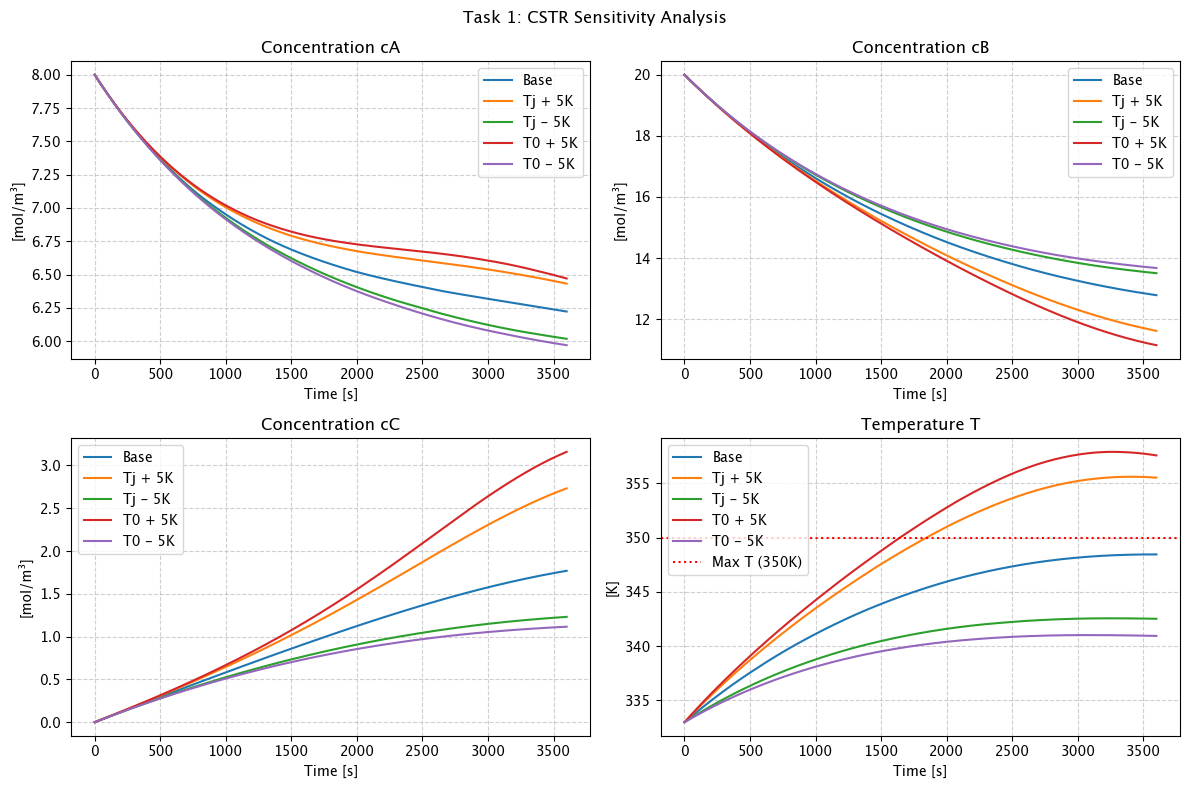

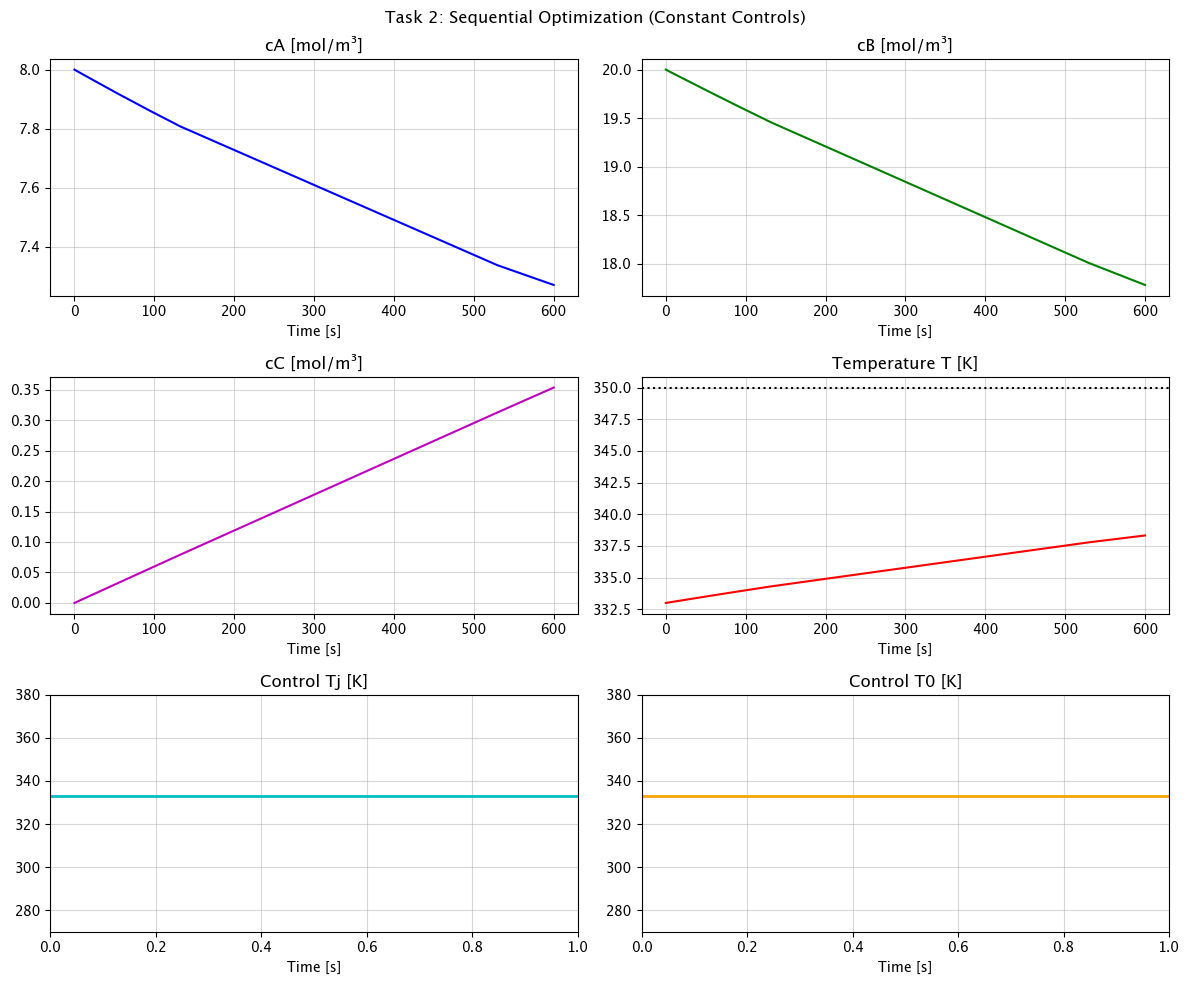

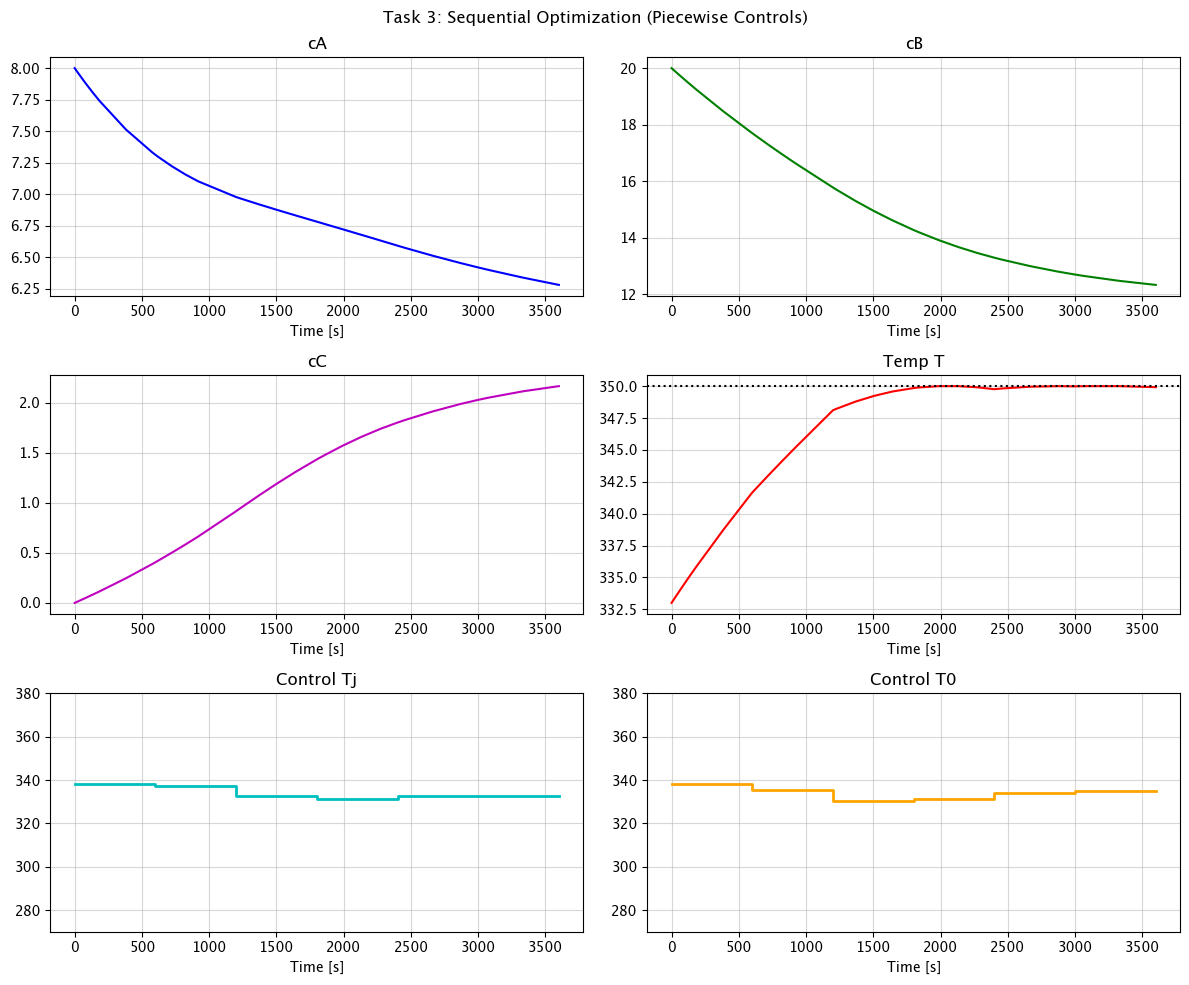

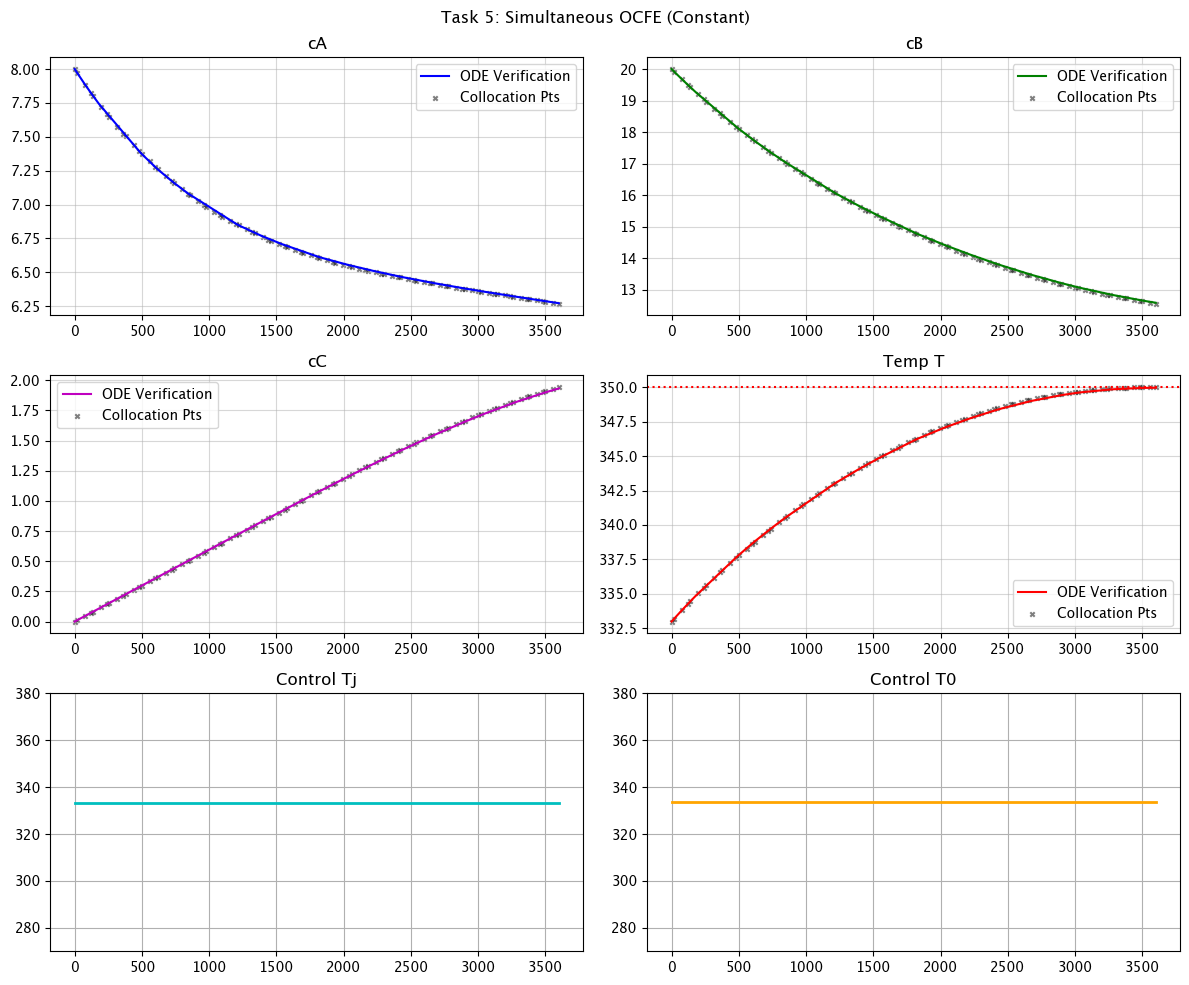

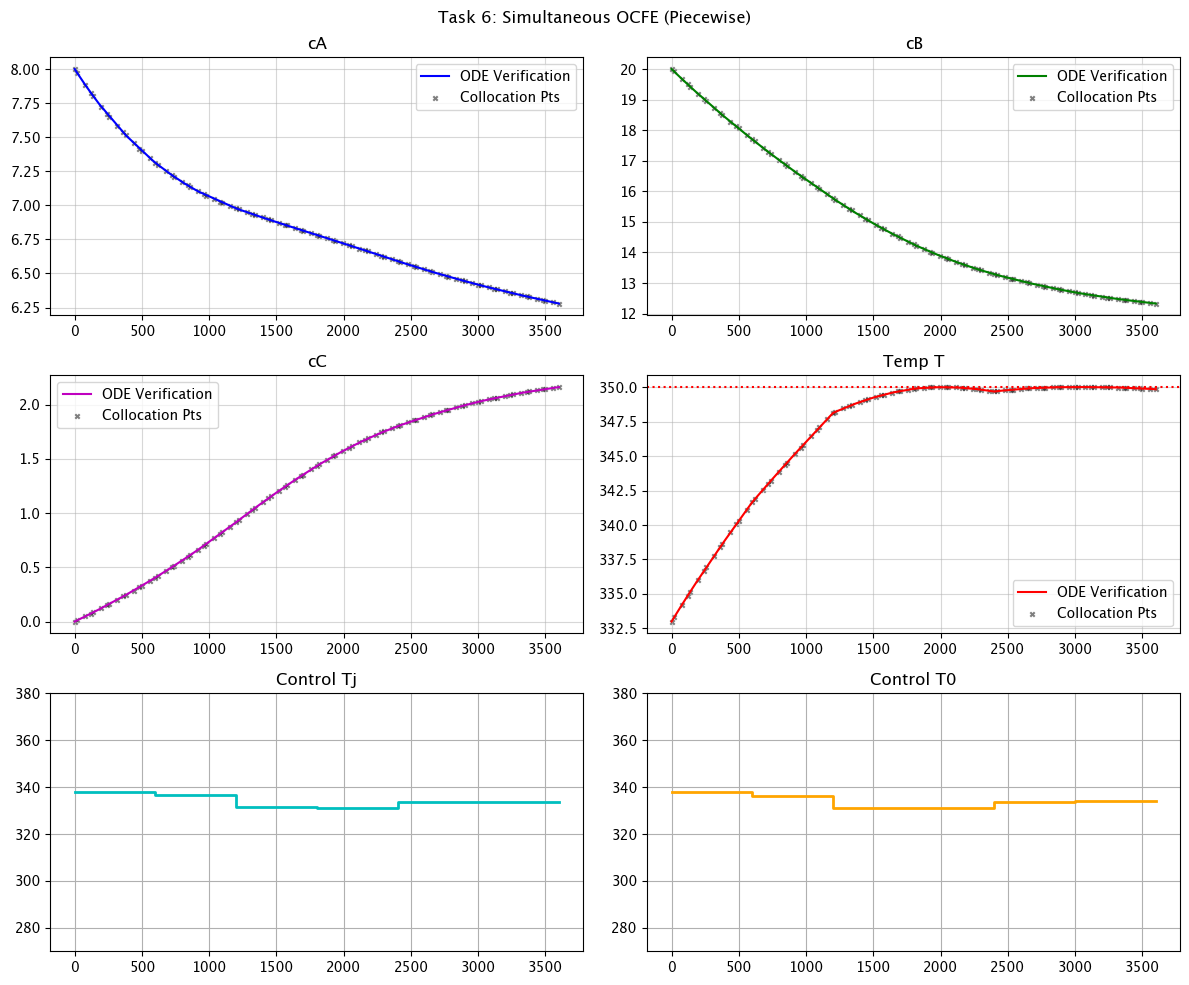

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize, LinearConstraint, NonlinearConstraint
import casadi as ca
import sys

# ==========================================
# CSTR SYSTEM PARAMETERS : (given)
# ==========================================
EA = 69000.0      # Activation energy A [J/mol]
EB = 72000.0      # Activation energy B [J/mol]
kA0 = 5.0e6       # Pre-exponential factor A [1/s]
kB0 = 1.0e7       # Pre-exponential factor B [1/s]
rho = 800.0       # Density [kg/m^3]
cp = 3.5          # Heat capacity [J/(kg K)] - Note: Used exactly as written in assignment
UA = 1.4          # Heat transfer coefficient * Area [W/K]
dHA = 45000.0     # Heat of reaction A [J/mol] (Endothermic)
dHB = -55000.0    # Heat of reaction B [J/mol] (Exothermic)
F = 6.5e-4        # Flow rate [m^3/s]
V = 1.0           # Volume [m^3]
R = 8.314         # Universal gas constant [J/(mol K)]

# Feed properties
cA0_feed = 5.0    # Feed concentration A [mol/m^3]
cB0_feed = 15.0   # Feed concentration B [mol/m^3]
cC0_feed = 0.0    # Feed concentration C [mol/m^3]

# Initial Conditions (t = 0)
x0 = [8.0, 20.0, 0.0, 333.0] # [cA, cB, cC, T]
T_init = 333.0
Tj_init = 333.0
T0_init = 333.0

# Constraints
T_max = 350.0
u_min, u_max = 273.0, 373.0
du_max = 5.0
horizon = 3600.0  # 1 hour
dt_control = 600.0 # 10 minutes interval

# ==========================================
# 1. ODE MODEL (Tasks 1, 2, 3)
# ==========================================
def cstr_ode(t, x, Tj, T0):
    """
    Differential equations for the CSTR.
    Reactions: 1) A -> C (Undesired), 2) B -> A (Desired product)
    """
    cA, cB, cC, T = x
    
    # Clip T dynamically during optimization explorations to prevent exp() overflow
    T_safe = np.clip(T, 200.0, 500.0)
    
    # Arrhenius kinetics considered constant here 
    kA = kA0 * np.exp(-EA / (R * T_safe))
    kB = kB0 * np.exp(-EB / (R * T_safe))
    
    # Mass balances
    dcA = (F/V) * (cA0_feed - cA) - kA * cA + kB * cB
    dcB = (F/V) * (cB0_feed - cB) - kB * cB
    dcC = (F/V) * (cC0_feed - cC) + kA * cA
    
    # Energy balance
    dT = (F/V) * (T0 - T) + (UA / (rho * cp * V)) * (Tj - T) \
         + (-dHA / (rho * cp)) * kA * cA \
         + (-dHB / (rho * cp)) * kB * cB
         
    return [dcA, dcB, dcC, dT]


# ==========================================
# TASK 1: SIMULATION & SENSITIVITY
# ==========================================
def run_task1():
    print("\n--- TASK 1: Simulation & Sensitivity ---")
    print("SOLVER DISCUSSION:")
    print("The ODEs exhibit 'stiffness' due to exponential Arrhenius terms (fast dynamics) ")
    print("running alongside a long 3600s horizon (slow dynamics). Explicit solvers like ode45 ")
    print("struggle and take microscopic steps. An implicit solver like 'ode15s' (Matlab) ")
    print("or 'BDF'/'Radau' (Python) computes the Jacobian to take stable, large steps, ")
    print("making it the superior and necessary choice here.\n")

    t_span = [0, horizon]
    
    # Scenarios: Base, Tj+5, Tj-5, T0+5, T0-5
    scenarios = [
        ("Base", 333.0, 333.0),
        ("Tj + 5K", 338.0, 333.0),
        ("Tj - 5K", 328.0, 333.0),
        ("T0 + 5K", 333.0, 338.0),
        ("T0 - 5K", 333.0, 328.0)
    ]
    
    results = {}
    for name, Tj, T0 in scenarios:
        # Using BDF (equivalent to ode15s) for stiffness
        sol = solve_ivp(cstr_ode, t_span, x0, args=(Tj, T0), method='BDF', dense_output=True)
        results[name] = sol

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('Task 1: CSTR Sensitivity Analysis')
    
    labels = ['Concentration cA', 'Concentration cB', 'Concentration cC', 'Temperature T']
    ylabels = ['[mol/m³]', '[mol/m³]', '[mol/m³]', '[K]']
    
    for name, sol in results.items():
        t_plot = np.linspace(0, horizon, 500)
        y_plot = sol.sol(t_plot)
        
        axs[0,0].plot(t_plot, y_plot[0], label=name)
        axs[0,1].plot(t_plot, y_plot[1], label=name)
        axs[1,0].plot(t_plot, y_plot[2], label=name)
        axs[1,1].plot(t_plot, y_plot[3], label=name)

    for i, ax in enumerate(axs.flat):
        ax.set_title(labels[i])
        ax.set_xlabel('Time [s]')
        ax.set_ylabel(ylabels[i])
        ax.grid(True, linestyle='--', alpha=0.6)
        if i == 3: # Add max temp constraint line
            ax.axhline(350, color='r', linestyle=':', label='Max T (350K)')
        ax.legend()
        
    plt.tight_layout()
    plt.savefig('task1_sensitivity.png')
    print("Saved 'task1_sensitivity.png'")


# ==========================================
# TASK 2: SEQUENTIAL OPTIMIZATION (CONSTANT)
# ==========================================
def simulate_for_opt(u_array, steps=1):
    """ Helper to simulate the system piece by piece (or as a whole) """
    t_eval_all, y_eval_all = [], []
    x_curr = x0
    
    for i in range(steps):
        Tj = u_array[2*i]
        T0 = u_array[2*i + 1]
        t_span = [i * dt_control, (i+1) * dt_control]
        # Relaxed tolerances for faster finite differences in optimization
        sol = solve_ivp(cstr_ode, t_span, x_curr, args=(Tj, T0), method='BDF', rtol=1e-3, atol=1e-6)
        
        t_eval_all.append(sol.t[:-1])
        y_eval_all.append(sol.y[:, :-1])
        x_curr = sol.y[:, -1]
        
    t_eval_all.append([sol.t[-1]])
    y_eval_all.append(sol.y[:, -1:])
    
    return np.concatenate(t_eval_all), np.concatenate(y_eval_all, axis=1)

def run_task2():
    print("\n--- TASK 2: Sequential Optimization (Constant Controls) ---")
    
    # Objective: Maximize integral of cA (by minimizing negative integral)
    def obj(u):
        t, y = simulate_for_opt(u, steps=1)
        return -np.trapezoid(y[0], t)
        
    # Constraint: Max Temp <= 350
    def temp_con(u):
        t, y = simulate_for_opt(u, steps=1)
        return 350.0 - np.max(y[3]) # Must be >= 0

    # Variables: [Tj, T0] applied for 3600s
    bounds = [(u_min, u_max), (u_min, u_max)]
    u_guess = [333.0, 333.0]
    nlc = NonlinearConstraint(temp_con, 0.0, np.inf)

    print("Optimizing with SLSQP (Finite differences)... Please wait (~10s).")
    res = minimize(obj, u_guess, bounds=bounds, constraints=[nlc], method='SLSQP', options={'disp': True})
    
    t_opt, y_opt = simulate_for_opt(res.x, steps=1)
    
    fig, axs = plt.subplots(3, 2, figsize=(12, 10))
    fig.suptitle('Task 2: Sequential Optimization (Constant Controls)')
    
    axs[0,0].plot(t_opt, y_opt[0], 'b-')
    axs[0,0].set_title('cA [mol/m³]')
    axs[0,1].plot(t_opt, y_opt[1], 'g-')
    axs[0,1].set_title('cB [mol/m³]')
    axs[1,0].plot(t_opt, y_opt[2], 'm-')
    axs[1,0].set_title('cC [mol/m³]')
    axs[1,1].plot(t_opt, y_opt[3], 'r-')
    axs[1,1].axhline(350, color='k', linestyle=':')
    axs[1,1].set_title('Temperature T [K]')
    
    axs[2,0].axhline(res.x[0], color='c', linewidth=2)
    axs[2,0].set_title('Control Tj [K]')
    axs[2,0].set_ylim(270, 380)
    axs[2,1].axhline(res.x[1], color='orange', linewidth=2)
    axs[2,1].set_title('Control T0 [K]')
    axs[2,1].set_ylim(270, 380)
    
    for ax in axs.flat:
        ax.grid(True, alpha=0.5)
        ax.set_xlabel('Time [s]')
        
    plt.tight_layout()
    plt.savefig('task2_seq_opt_constant.png')
    print("Saved 'task2_seq_opt_constant.png'")


# ==========================================
# TASK 3: SEQUENTIAL OPTIMIZATION (PIECEWISE)
# ==========================================
def run_task3():
    print("\n--- TASK 3: Sequential Optimization (Piecewise Controls) ---")
    
    # 6 intervals of 10 minutes. Variables: [Tj0, T00, Tj1, T01, ... Tj5, T05]
    n_intervals = int(horizon / dt_control)
    
    def obj(u):
        t, y = simulate_for_opt(u, steps=n_intervals)
        return -np.trapezoid(y[0], t)
        
    def temp_con(u):
        t, y = simulate_for_opt(u, steps=n_intervals)
        return 350.0 - np.max(y[3])
    
    # Bounds setup
    bounds = []
    for i in range(n_intervals):
        if i == 0:
            # Initial step max 5K from 333
            bounds.append((max(u_min, 333-du_max), min(u_max, 333+du_max)))
            bounds.append((max(u_min, 333-du_max), min(u_max, 333+du_max)))
        else:
            bounds.append((u_min, u_max))
            bounds.append((u_min, u_max))

    # Step rate constraints: -5 <= U[k] - U[k-1] <= 5
    A_diff = np.zeros((10, 12))
    for i in range(1, 6):
        A_diff[2*(i-1), 2*i] = 1.0       # Tj_k
        A_diff[2*(i-1), 2*(i-1)] = -1.0  # Tj_{k-1}
        A_diff[2*(i-1)+1, 2*i+1] = 1.0   # T0_k
        A_diff[2*(i-1)+1, 2*(i-1)+1] = -1.0 # T0_{k-1}
        
    lin_con = LinearConstraint(A_diff, -du_max, du_max)
    nlc = NonlinearConstraint(temp_con, 0.0, np.inf)
    
    u_guess = [333.0] * 12
    
    print("Optimizing with SLSQP... This requires evaluating sensitivities for 12 variables via FD.")
    print("Please wait (~1-2 minutes). For exact Jacobians, one would implement sensitivity ODEs (Bonus!).")
    res = minimize(obj, u_guess, bounds=bounds, constraints=[lin_con, nlc], method='SLSQP', options={'disp': True})
    
    t_opt, y_opt = simulate_for_opt(res.x, steps=n_intervals)
    
    # Plotting
    fig, axs = plt.subplots(3, 2, figsize=(12, 10))
    fig.suptitle('Task 3: Sequential Optimization (Piecewise Controls)')
    
    axs[0,0].plot(t_opt, y_opt[0], 'b-')
    axs[0,1].plot(t_opt, y_opt[1], 'g-')
    axs[1,0].plot(t_opt, y_opt[2], 'm-')
    axs[1,1].plot(t_opt, y_opt[3], 'r-')
    axs[1,1].axhline(350, color='k', linestyle=':')
    
    # Extract controls for step plotting
    t_u = np.arange(0, horizon + 1, dt_control)
    Tj_vals = [res.x[2*i] for i in range(6)] + [res.x[-2]]
    T0_vals = [res.x[2*i+1] for i in range(6)] + [res.x[-1]]
    
    axs[2,0].step(t_u, Tj_vals, where='post', color='c', linewidth=2)
    axs[2,0].set_ylim(270, 380)
    axs[2,1].step(t_u, T0_vals, where='post', color='orange', linewidth=2)
    axs[2,1].set_ylim(270, 380)
    
    titles = ['cA', 'cB', 'cC', 'Temp T', 'Control Tj', 'Control T0']
    for i, ax in enumerate(axs.flat):
        ax.set_title(titles[i])
        ax.grid(True, alpha=0.5)
        ax.set_xlabel('Time [s]')
        
    plt.tight_layout()
    plt.savefig('task3_seq_opt_piecewise.png')
    print("Saved 'task3_seq_opt_piecewise.png'")
    
    return res.x


# ==========================================
# TASKS 4, 5, 6: SIMULTANEOUS OPTIMIZATION
# ==========================================
def run_simultaneous_tasks(constant_control=False):
    """
    Implements Orthogonal Collocation on Finite Elements (OCFE)
    using CasADi. Handles both Task 5 (constant) and Task 6 (piecewise).
    """
  
    task_num = 5 if constant_control else 6
    print(f"\n--- TASK {task_num}: Simultaneous Optimization (OCFE) ---")
    
    # Collocation parameters
    N = 30 # 30 finite elements (5 per 10 min interval)
    d = 3  # Degree of collocation polynomial
    
    # Radau collocation roots
    tau = ca.collocation_points(d, 'radau')
    tau_root = [0.0] + tau
    
    # Calculate collocation coefficient matrices
    C = np.zeros((d+1, d+1))
    D = np.zeros(d+1)
    
    for j in range(d+1):
        p = np.poly1d([1.0])
        for r in range(d+1):
            if r != j:
                p = np.polymul(p, [1.0, -tau_root[r]]) / (tau_root[j] - tau_root[r])
        dp = np.polyder(p)
        for r in range(d+1):
            C[j, r] = dp(tau_root[r])
        D[j] = p(1.0)
        
    # System dimensions
    nx = 5 # [cA, cB, cC, T, q (quadrature for objective)]
    nu = 2 # [Tj, T0]
    
    # Symbolic ODE evaluation
    x_sym = ca.SX.sym('x', nx)
    u_sym = ca.SX.sym('u', nu)
    
    cA, cB, cC, T, q = x_sym[0], x_sym[1], x_sym[2], x_sym[3], x_sym[4]
    Tj, T0 = u_sym[0], u_sym[1]
    
    kA = kA0 * ca.exp(-EA / (R * T))
    kB = kB0 * ca.exp(-EB / (R * T))
    
    dcA = (F/V) * (cA0_feed - cA) - kA * cA + kB * cB
    dcB = (F/V) * (cB0_feed - cB) - kB * cB
    dcC = (F/V) * (cC0_feed - cC) + kA * cA
    dT = (F/V) * (T0 - T) + (UA / (rho * cp * V)) * (Tj - T) \
         + (-dHA / (rho * cp)) * kA * cA + (-dHB / (rho * cp)) * kB * cB
    dq = cA # Integration of cA
    
    ode_rhs = ca.vertcat(dcA, dcB, dcC, dT, dq)
    f_dae = ca.Function('f_dae', [x_sym, u_sym], [ode_rhs])
    
    w = []
    w0 = []
    lbw = []
    ubw = []
    
    g = []
    lbg = []
    ubg = []
    
    # Initial State
    X_k = ca.MX.sym('X0', nx)
    w.append(X_k)
    lbw.extend([x0[0], x0[1], x0[2], x0[3], 0.0])
    ubw.extend([x0[0], x0[1], x0[2], x0[3], 0.0])
    w0.extend([x0[0], x0[1], x0[2], x0[3], 0.0])
    
    h = horizon / N
    
    if constant_control:
        # One control variable for the entire horizon
        Uk = ca.MX.sym('U_const', nu)
        w.append(Uk)
        lbw.extend([u_min, u_min])
        ubw.extend([u_max, u_max])
        w0.extend([333.0, 333.0])
        
        # Limit initial step
        g.append(Uk[0] - 333.0)
        g.append(Uk[1] - 333.0)
        lbg.extend([-du_max, -du_max])
        ubg.extend([du_max, du_max])

    U_prev = None
    
    for k in range(N):
        interval = k // 5 # 5 elements per 10-min interval
        
        if not constant_control and k % 5 == 0:
            Uk = ca.MX.sym(f'U_{interval}', nu)
            w.append(Uk)
            lbw.extend([u_min, u_min])
            ubw.extend([u_max, u_max])
            w0.extend([333.0, 333.0])
            
            if interval == 0:
                g.append(Uk[0] - 333.0)
                g.append(Uk[1] - 333.0)
            else:
                g.append(Uk[0] - U_prev[0])
                g.append(Uk[1] - U_prev[1])
            lbg.extend([-du_max, -du_max])
            ubg.extend([du_max, du_max])
            
            U_prev = Uk

        # Collocation states for the current element
        X_kj = []
        for j in range(1, d+1):
            x_var = ca.MX.sym(f'X_{k}_{j}', nx)
            w.append(x_var)
            # Apply T <= 350 strictly to all collocation points
            lbw.extend([0, 0, 0, 200, 0])
            ubw.extend([100, 100, 100, T_max, ca.inf])
            w0.extend([x0[0], x0[1], x0[2], x0[3], 0.0])
            X_kj.append(x_var)
            
        # Collocation constraints
        for j in range(1, d+1):
            xp = C[0, j] * X_k
            for r in range(1, d+1):
                xp = xp + C[r, j] * X_kj[r-1]
                
            dx = f_dae(X_kj[j-1], Uk)
            g.append(h * dx - xp)
            lbg.extend([0]*nx)
            ubg.extend([0]*nx)
            
        # Radau root places end state exactly at X_kj[-1]
        X_k = X_kj[-1]
        
    # Objective: Maximize quadrature state (integral of cA)
    J = -X_k[4]
    
    nlp = {'f': J, 'x': ca.vertcat(*w), 'g': ca.vertcat(*g)}
    opts = {'ipopt.print_level': 4, 'print_time': False}
    solver = ca.nlpsol('solver', 'ipopt', nlp, opts)
    
    print(f"Solving NLP with {ca.vertcat(*w).shape[0]} variables...")
    sol = solver(x0=ca.vertcat(*w0), lbx=ca.vertcat(*lbw), ubx=ca.vertcat(*ubw),
                 lbg=ca.vertcat(*lbg), ubg=ca.vertcat(*ubg))
                 
    w_opt = sol['x'].full().flatten()
    
    # Data extraction
    t_opt_pts = [0.0]
    X_opt_pts = [w_opt[:5]]
    
    u_trajectory = []
    idx = 5
    
    if constant_control:
        u_val = w_opt[idx:idx+2]
        idx += 2
        for _ in range(6): u_trajectory.extend(u_val)
    
    for k in range(N):
        if not constant_control and k % 5 == 0:
            u_val = w_opt[idx:idx+2]
            u_trajectory.extend(u_val)
            idx += 2
            
        t_start = k * h
        for j in range(1, d+1):
            X_opt_pts.append(w_opt[idx:idx+5])
            t_opt_pts.append(t_start + h * tau_root[j])
            idx += 5
            
    X_opt_pts = np.array(X_opt_pts).T
    
    # Task 4 Check: Simulate Optimal Control via scipy ODE to verify collocation accuracy
    t_sim, y_sim = simulate_for_opt(u_trajectory, steps=6)
    
    # Plotting
    fig, axs = plt.subplots(3, 2, figsize=(12, 10))
    fig.suptitle(f'Task {task_num}: Simultaneous OCFE ({"Constant" if constant_control else "Piecewise"})')
    
    colors = ['b', 'g', 'm', 'r']
    titles = ['cA', 'cB', 'cC', 'Temp T']
    
    for i in range(4):
        ax = axs[i//2, i%2]
        # Plot continuous ODE verification
        ax.plot(t_sim, y_sim[i], color=colors[i], label='ODE Verification')
        # Overlay collocation points
        ax.scatter(t_opt_pts, X_opt_pts[i], color='k', s=10, marker='x', alpha=0.5, label='Collocation Pts')
        ax.set_title(titles[i])
        ax.grid(True, alpha=0.5)
        ax.legend()
        if i == 3: ax.axhline(350, color='r', linestyle=':')
        
    t_u = np.arange(0, horizon + 1, dt_control)
    Tj_vals = [u_trajectory[2*i] for i in range(6)] + [u_trajectory[-2]]
    T0_vals = [u_trajectory[2*i+1] for i in range(6)] + [u_trajectory[-1]]
    
    axs[2,0].step(t_u, Tj_vals, where='post', color='c', linewidth=2)
    axs[2,0].set_title('Control Tj')
    axs[2,0].set_ylim(270, 380)
    axs[2,0].grid(True)
    
    axs[2,1].step(t_u, T0_vals, where='post', color='orange', linewidth=2)
    axs[2,1].set_title('Control T0')
    axs[2,1].set_ylim(270, 380)
    axs[2,1].grid(True)
    
    plt.tight_layout()
    plt.savefig(f'task{task_num}_simultaneous_opt.png')
    print(f"Saved 'task{task_num}_simultaneous_opt.png'")


# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == '__main__':
    print("="*60)
    print(" CSTR OPTIMIZATION PROJECT - SEQUENTIAL VS SIMULTANEOUS")
    print("="*60)
    
    # Task 1
    run_task1()
    
    # Task 2
    run_task2()
    
    # Task 3 
    # (The resulting trajectory would conceptually serve as w0 for Simultaneous Opt)
    opt_u_task3 = run_task3() 
    
    # Tasks 4, 5, 6
        # Task 5 (Simultaneous, Constant Controls)
    run_simultaneous_tasks(constant_control=True)
        # Task 6 (Simultaneous, Piecewise Controls, checking Task 4 accuracy)
    run_simultaneous_tasks(constant_control=False)
        
    print("\nAll tasks completed successfully. Output plots have been saved.")
    plt.show() # Display generated plots